In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns



In [2]:
# --- 1. Setup Sample Data ---
data = {
    'video_title': ['Intro to Python', 'SQL Basics', 'Pandas Tutorial', 'Data Viz', 'Machine Learning'],
    'views': [1500, 2200, 3100, 1800, 4500],
    'likes': [120, 200, 350, 150, 500],
    'comments': [10, 25, 40, 15, 60],
    'duration_min': [10, 15, 20, 12, 30]
}
df = pd.DataFrame(data)

In [3]:
# --- 2. SQL Database Integration ---
# Create an in-memory SQL database
conn = sqlite3.connect(':memory:')
df.to_sql('channel_data', conn, index=False)


5

In [4]:
# Query data from SQL
query = "SELECT * FROM channel_data WHERE views > 2000"
df_sql = pd.read_sql(query, conn)


In [5]:
# --- 3. Statistical Analysis ---
# Add calculated columns using NumPy/Pandas
df['engagement_rate'] = (df['likes'] + df['comments']) / df['views'] * 100
df['views_per_min'] = df['views'] / df['duration_min']

print("--- Channel Analytics Summary ---")
print(df[['video_title', 'engagement_rate', 'views_per_min']].sort_values(by='engagement_rate', ascending=False))

--- Channel Analytics Summary ---
        video_title  engagement_rate  views_per_min
2   Pandas Tutorial        12.580645     155.000000
4  Machine Learning        12.444444     150.000000
1        SQL Basics        10.227273     146.666667
3          Data Viz         9.166667     150.000000
0   Intro to Python         8.666667     150.000000


C:\Users\pranj\AppData\Local\Temp\ipykernel_13916\1962129120.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='video_title', y='views', data=df, palette='viridis')


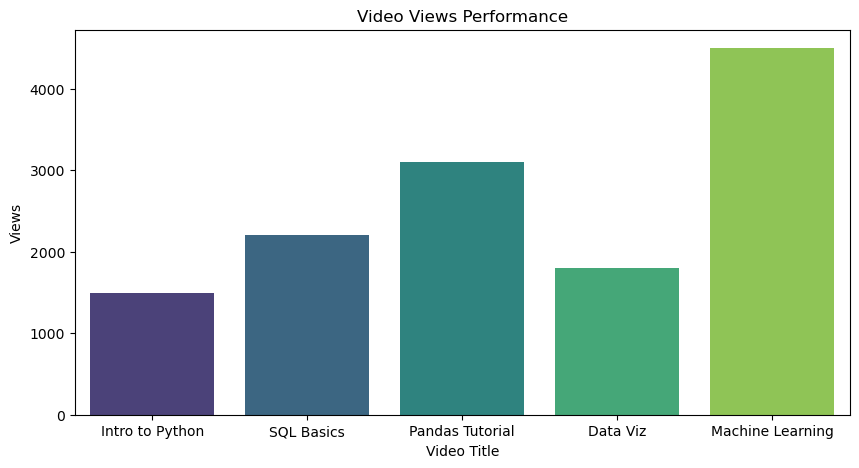

In [7]:
# --- 4. Visualization ---
plt.figure(figsize=(10, 5))
sns.barplot(x='video_title', y='views', data=df, palette='viridis')
plt.title('Video Views Performance')
plt.ylabel('Views')
plt.xlabel('Video Title')
plt.show()


In [ ]:
# Close connection
conn.close()